# 1. Data Collection, EDA, Cleaning & Labeling

**Dataset: CFPB Consumer Complaint Database** (real, live, public:- https://www.consumerfinance.gov/data-research/consumer-complaints/)

In [2]:
import sys, re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path.cwd().parent / 'src'))
from cfpb_download import download_sample
from category_urgency import map_urgency, URGENCY_LEVELS

DATA_DIR = Path.cwd().parent / 'data'
DATA_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)


## 1.1 Download a sample from the live CFPB API

We pull complaints across **20 separate date windows** spanning ~2.5 years. Each window makes a small API call, giving us a diverse sample without needing pagination.

The data is downloaded once and cached locally for later runs.

In [3]:
date_windows = [
    ("2023-01-01", "2023-02-15"),
    ("2023-02-15", "2023-04-01"),
    ("2023-04-01", "2023-05-15"),
    ("2023-05-15", "2023-07-01"),
    ("2023-07-01", "2023-08-15"),
    ("2023-08-15", "2023-10-01"),
    ("2023-10-01", "2023-11-15"),
    ("2023-11-15", "2024-01-01"),

    ("2024-01-01", "2024-02-15"),
    ("2024-02-15", "2024-04-01"),
    ("2024-04-01", "2024-05-15"),
    ("2024-05-15", "2024-07-01"),
    ("2024-07-01", "2024-08-15"),
    ("2024-08-15", "2024-10-01"),
    ("2024-10-01", "2024-11-15"),
    ("2024-11-15", "2025-01-01"),

    ("2025-01-01", "2025-03-01"),
    ("2025-03-01", "2025-05-01"),
    ("2025-05-01", "2025-07-01"),
    ("2025-07-01", "2025-09-01"),
]

In [4]:
raw_path = DATA_DIR / 'cfpb_raw.csv'

if raw_path.exists():
    df = pd.read_csv(raw_path)
    print(f'Loaded cached raw sample: {len(df)} rows')
else:
    df = download_sample(date_windows, rows_per_window=400)
    df.to_csv(raw_path, index=False)
    print(f'Downloaded and cached: {len(df)} rows -> {raw_path}')

df.head()

Loaded cached raw sample: 7999 rows


,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,has_narrative,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue
0,Debt collection,"THE CREDIT BUREAUS NEVER DID A PROPER "" INVESTIGATION '' ACCORDING TO FCRA. \n\nThe term "" investigation consumer re...",2023-03-14T16:22:13.000Z,Attempts to collect debt not owed,Other debt,85018,NaN,True,6578540,Yes,Closed with explanation,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2023-02-15T05:45:56.000Z,AZ,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Debt was paid
1,"Credit reporting, credit repair services, or other personal consumer reports","When I reviewed my credit report, I discovered that these accounts were erroneous. The 3 credit bureaus must validat...",2023-02-15T09:11:10.000Z,Problem with a credit reporting company's investigation into an existing problem,Credit reporting,46222,NaN,True,6578518,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2023-02-15T09:11:04.000Z,IN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Their investigation did not fix an error on your report
2,"Credit reporting, credit repair services, or other personal consumer reports","When I reviewed my credit report, I discovered that these accounts were erroneous. The 3 credit bureaus must validat...",2023-02-15T09:11:10.000Z,Problem with a credit reporting company's investigation into an existing problem,Credit reporting,46222,NaN,True,6578517,Yes,Closed with explanation,Web,"EQUIFAX, INC.",2023-02-15T09:11:04.000Z,IN,NaN,Their investigation did not fix an error on your report
3,"Credit reporting, credit repair services, or other personal consumer reports",My name is XXXX XXXX this complaint is not made in error neither is it being made by a third party.I declare under p...,2023-02-15T09:25:47.000Z,Problem with a credit reporting company's investigation into an existing problem,Credit reporting,60409,NaN,True,6578497,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2023-02-15T09:20:58.000Z,IL,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Their investigation did not fix an error on your report
4,"Credit reporting, credit repair services, or other personal consumer reports",Ive pulled my credit report and the account with XXXX XXXX Acct XXXX XXXX XXXX TransUnion XXXX XXXX and with XXXX Ac...,2023-02-15T09:19:54.000Z,Incorrect information on your report,Credit reporting,90019,NaN,True,6578496,Yes,Closed with non-monetary relief,Web,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2023-02-15T09:19:48.000Z,CA,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Account status incorrect


In [5]:
df.shape

(7999, 17)

## 1.2 Exploratory Data Analysis

Look at category balance, text length, and duplicates before touching anything.

In [6]:
print('Shape:', df.shape)
print('Null narrative:', df['complaint_what_happened'].isna().sum())
print('Duplicate narratives:', df.duplicated(subset=['complaint_what_happened']).sum())

df = df[df['complaint_what_happened'].notna() & (df['complaint_what_happened'].str.len() > 20)].reset_index(drop=True)
print('After dropping empty/very short narratives:', df.shape)


Shape: (7999, 17)
Null narrative: 0
Duplicate narratives: 2216
After dropping empty/very short narratives: (7998, 17)


product
Credit reporting or other personal consumer reports                             4512
Credit reporting, credit repair services, or other personal consumer reports    1511
Debt collection                                                                  665
Checking or savings account                                                      317
Credit card                                                                      270
Mortgage                                                                         175
Credit card or prepaid card                                                      144
Money transfer, virtual currency, or money service                               117
Student loan                                                                      84
Vehicle loan or lease                                                             76
Payday loan, title loan, personal loan, or advance loan                           51
Prepaid card                                             

C:\Users\narul\AppData\Local\Temp\ipykernel_7700\617618040.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


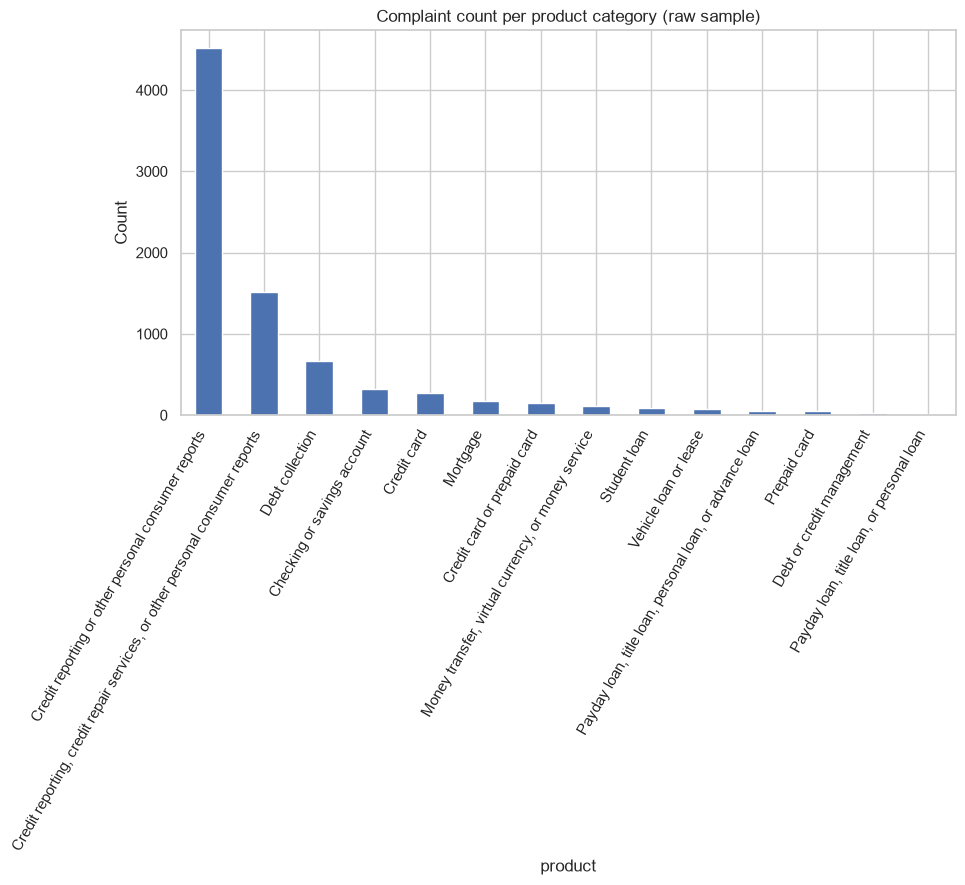

In [7]:
product_counts = df['product'].value_counts()
print(product_counts)

plt.figure(figsize=(10,5))
product_counts.plot(kind='bar')
plt.title('Complaint count per product category (raw sample)')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


In [8]:
# Merge duplicate/overlapping CFPB category naming
# ("Credit reporting or other personal consumer reports" is the old name;
#  "Credit reporting, credit repair services, or other personal consumer reports"
#  is the current CFPB name for the same category)
category_merge_map = {
    'Credit reporting or other personal consumer reports':
        'Credit reporting, credit repair services, or other personal consumer reports',
}

df['product'] = df['product'].replace(category_merge_map)

print(df['product'].value_counts())

product
Credit reporting, credit repair services, or other personal consumer reports    6023
Debt collection                                                                  665
Checking or savings account                                                      317
Credit card                                                                      270
Mortgage                                                                         175
Credit card or prepaid card                                                      144
Money transfer, virtual currency, or money service                               117
Student loan                                                                      84
Vehicle loan or lease                                                             76
Payday loan, title loan, personal loan, or advance loan                           51
Prepaid card                                                                      45
Debt or credit management                                

## 1.3 Keep only the top N categories

Same reasoning as any real triage system: you support your top N departments
well rather than 40 categories with 10 examples each. We pick `TOP_N`
categories by volume.This list is **not** hard-coded, so it stays correct
even as CFPB renames/reorganizes categories over time.

In [9]:
TOP_N = 8
top_categories = product_counts.head(TOP_N).index.tolist()
print('Keeping categories:')
for c in top_categories:
    print(f'  - {c}  ({product_counts[c]} complaints)')

df = df[df['product'].isin(top_categories)].reset_index(drop=True)
print(f'\nRemaining rows: {len(df)}')


Keeping categories:
  - Credit reporting or other personal consumer reports  (4512 complaints)
  - Credit reporting, credit repair services, or other personal consumer reports  (1511 complaints)
  - Debt collection  (665 complaints)
  - Checking or savings account  (317 complaints)
  - Credit card  (270 complaints)
  - Mortgage  (175 complaints)
  - Credit card or prepaid card  (144 complaints)
  - Money transfer, virtual currency, or money service  (117 complaints)

Remaining rows: 7711


## 1.4 Text cleaning

Real complaint text has redacted PII shown as `XXXX`, we keep that token
(it's informative: lots of `XXXX` often means financial account details are
being discussed) but remove whitespace and strip control characters.

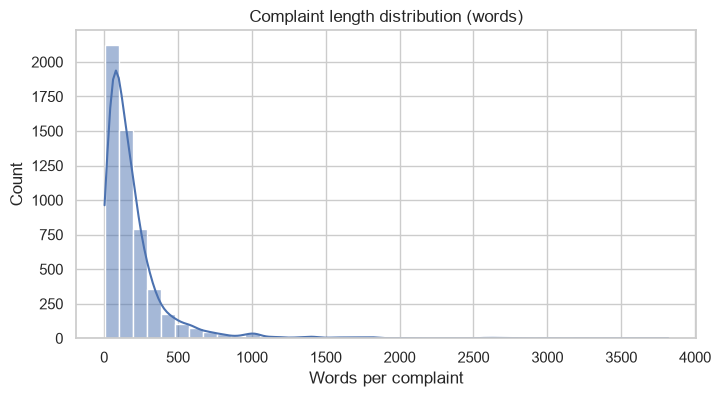

count    5338.000000
mean      196.796553
std       248.575920
min         3.000000
25%        67.000000
50%       128.500000
75%       230.750000
max      3818.000000
Name: word_count, dtype: float64


In [10]:
def clean_text(t: str) -> str:
    t = str(t).strip()
    t = re.sub(r'\s+', ' ', t)
    t = re.sub(r'[^\w\s?!.,\'\-]', '', t)
    return t.strip()

df['text'] = df['complaint_what_happened'].apply(clean_text)
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
df['word_count'] = df['text'].str.split().str.len()

plt.figure(figsize=(8,4))
sns.histplot(df['word_count'], bins=40, kde=True)
plt.title('Complaint length distribution (words)')
plt.xlabel('Words per complaint')
plt.show()
print(df['word_count'].describe())


## 1.5 Urgency labeling (rule-based, keyword rubric)

CFPB has no urgency field, so we build one from a
documented rubric, this time based on keywords in `issue` / `sub_issue`
(see `src/category_urgency.py` for the exact word lists and reasoning).


urgency
low       2081
medium    2962
high       295
Name: count, dtype: int64
urgency
low       39.0%
medium    55.5%
high       5.5%
Name: count, dtype: str


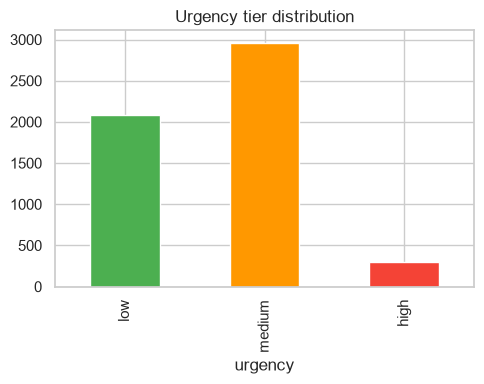

In [11]:
df['urgency'] = map_urgency(df['issue'], df['sub_issue'])
df['urgency'] = pd.Categorical(df['urgency'], categories=URGENCY_LEVELS, ordered=True)

urgency_counts = df['urgency'].value_counts().reindex(URGENCY_LEVELS)
print(urgency_counts)
print((urgency_counts / len(df) * 100).round(1).astype(str) + '%')

plt.figure(figsize=(5,4))
urgency_counts.plot(kind='bar', color=['#4caf50','#ff9800','#f44336'])
plt.title('Urgency tier distribution')
plt.tight_layout()
plt.show()


## 1.6 Save cleaned dataset for downstream notebooks

In [12]:
out_cols = ['text', 'product', 'issue', 'sub_issue', 'urgency', 'word_count']
df[out_cols].to_csv(DATA_DIR / 'cfpb_clean.csv', index=False)
print(f'Saved cleaned dataset -> {DATA_DIR / "cfpb_clean.csv"}')
print(f'Shape: {df.shape}')
print(f'Categories: {sorted(df["product"].unique())}')

Saved cleaned dataset -> C:\Users\narul\Documents\cfpb_triage_final\data\cfpb_clean.csv
Shape: (5338, 20)
Categories: ['Checking or savings account', 'Credit card', 'Credit card or prepaid card', 'Credit reporting, credit repair services, or other personal consumer reports', 'Debt collection', 'Money transfer, virtual currency, or money service', 'Mortgage']
